In [1]:
import onep
import scipy
import scipy.stats
%matplotlib inline

In [2]:
import pickle

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

In [5]:
collection_fc.animals['astroF3'].accepted_traces

TypeError: 'dCA1Group' object is not subscriptable

In [36]:
import numpy as np
import scipy.interpolate
import matplotlib.pyplot as plt
import seaborn as sns

def get_traces(collection, animals, stop_index=3303):
    return np.hstack([
        collection.animals[a].accepted_traces.to_numpy()[:stop_index, :]
        for a in animals
    ])

# Define animals for each group
mouse_ids = ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF8', 'astroF9', 'astroF10','astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']

# Collect data from collections
fcA_array = get_traces(collection_fc, mouse_ids)

def shock_eta_all(data, timestamps, events=None, window=15, ci='tci', sig_duration=10, ax=None, **kwargs):
    """
    Computes average trace around events (ETAs) and plots it with confidence intervals and significance markers.

    Parameters:
        data (np.ndarray): Cells x Time array.
        timestamps (np.ndarray): Timestamps aligned with data.
        events (list of lists): List of lists of event times per cell.
        window (int): Seconds of data to include post-event.
        ci (str): 'tci' or 'bci' for confidence interval method.
        sig_duration (int): Minimum duration (in points) for a segment to be considered significant.
        ax (matplotlib.axes): Optional existing axis to plot on.
        kwargs: Additional plotting arguments for the line.

    Returns:
        ax: The axis object with the plot.
        across_eta_: Averaged data across all events and cells.
    """
    sampling_rate = 10  # Adjust if needed
    n_points = int(window * 1.5 * sampling_rate)
    time = np.linspace(-window / 2, window, n_points)

    def event_interpolation(signal, event_times):
        interp = scipy.interpolate.interp1d(timestamps, signal, kind='cubic', fill_value="extrapolate")
        eta_curves = np.array([
            interp(np.linspace(e - window / 2, e + window, n_points))
            for e in event_times
        ])
        return eta_curves.mean(axis=0)

    if len(events) == 1:
        events = events * len(data)

    across_eta_ = np.array([
        event_interpolation(signal, ev) for signal, ev in zip(data, events)
    ])

    avg_trace = across_eta_.mean(axis=0)

    if ci == 'tci':
        c_int = onep.tci(across_eta_)
    elif ci == 'bci':
        c_int = onep.bci(across_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval must be 'tci' or 'bci'")

    sig_starts = onep.eta_significance(c_int[0, :], sig_duration=sig_duration)

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(time, avg_trace, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    # Draw horizontal significance bars
    y_marker = ax.get_ylim()[1] * 0.97
    for s in sig_starts:
        if s + sig_duration < len(time):
            ax.hlines(y=y_marker, xmin=time[s], xmax=time[s + sig_duration], linewidth=2)

    return ax, across_eta_


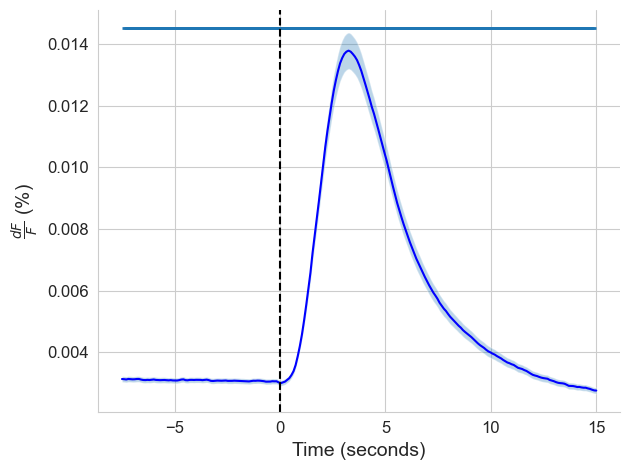

In [17]:
#Plot using the above function

fig, ax = plt.subplots()
sns.set_style("ticks")

# Shared timestamps (from a valid mouse)
timestamps = collection_fc.animals['astroM4'].Timestamps[:3303].to_numpy().squeeze()
shock_events = [[120, 180, 240, 300]]

shock_eta_all(fcA_array.T, timestamps, events=shock_events, window=15, ci='tci', ax=ax, color='blue')

ax.axvline(x=0, color='black', linestyle='--')
ax.set_xlabel('Time (seconds)', fontsize=14)
ax.set_ylabel(r'$\frac{dF}{F}$ (%)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [37]:
import numpy as np
import scipy.interpolate
import matplotlib.pyplot as plt
import seaborn as sns


def get_traces(collection, animals, stop_index=3303):
    return np.hstack([
        collection.animals[a].accepted_traces.to_numpy()[:stop_index, :]
        for a in animals
    ])


# Define animals for each group
mouse_ids = ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF8', 'astroF9', 'astroF10',
             'astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']

# Collect data from collections
fcA_array = get_traces(collection_fc, mouse_ids)


def shock_eta_all(data, timestamps, events=None, window=15, ci='tci', sig_duration=10, ax=None, **kwargs):
    sampling_rate = 10  # Hz, adjust if needed
    n_points = int(window * 1.5 * sampling_rate)
    time = np.linspace(-window / 2, window, n_points)

    def event_interpolation(signal, event_times):
        interp = scipy.interpolate.interp1d(timestamps, signal, kind='cubic', fill_value="extrapolate")
        eta_curves = np.array([
            interp(np.linspace(e - window / 2, e + window, n_points))
            for e in event_times
        ])
        return eta_curves.mean(axis=0)

    if len(events) == 1:
        events = events * len(data)

    across_eta_ = np.array([
        event_interpolation(signal, ev) for signal, ev in zip(data, events)
    ])

    # Define baseline period: -5 to -3 seconds relative to event
    baseline_indices = np.where((time >= -5) & (time <= -3))[0]
    # Compute mean baseline per trace
    baseline_means = across_eta_[:, baseline_indices].mean(axis=1, keepdims=True)
    # Subtract baseline from each trace
    across_eta_ = across_eta_ - baseline_means

    avg_trace = across_eta_.mean(axis=0)

    if ci == 'tci':
        c_int = onep.tci(across_eta_)
    elif ci == 'bci':
        c_int = onep.bci(across_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval must be 'tci' or 'bci'")

    sig_starts = onep.eta_significance(c_int[0, :], sig_duration=sig_duration)

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(time, avg_trace, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    y_marker = ax.get_ylim()[1] * 0.97
    for s in sig_starts:
        if s + sig_duration < len(time):
            ax.hlines(y=y_marker, xmin=time[s], xmax=time[s + sig_duration], linewidth=1, color='black')

    return ax, across_eta_

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_shock_eta_all(data, timestamps, events, title="", save_path=None):
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5,3.5), dpi=600)
    sns.set(style="ticks", font="Arial")
    shock_eta_all(data.T, timestamps, events=events, window=15, ci='tci', ax=ax, color='#B39BC8')

    ax.axvline(x=0, color='black', linestyle='--')
    ax.text(0, ax.get_ylim()[1] * 1.02, 'Shock Onset', ha='center', va='bottom', fontsize=8, fontname='Arial')
    ax.set_ylabel(r"ΔF/F (need to multipy all values by 100 for %)", fontsize=10, fontname='Arial', labelpad=15)
    ax.set_xlabel('Time (s)', fontsize=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    ax.set_title(title, fontsize=10, pad=10, fontname='Arial')
    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()

    return fig, ax

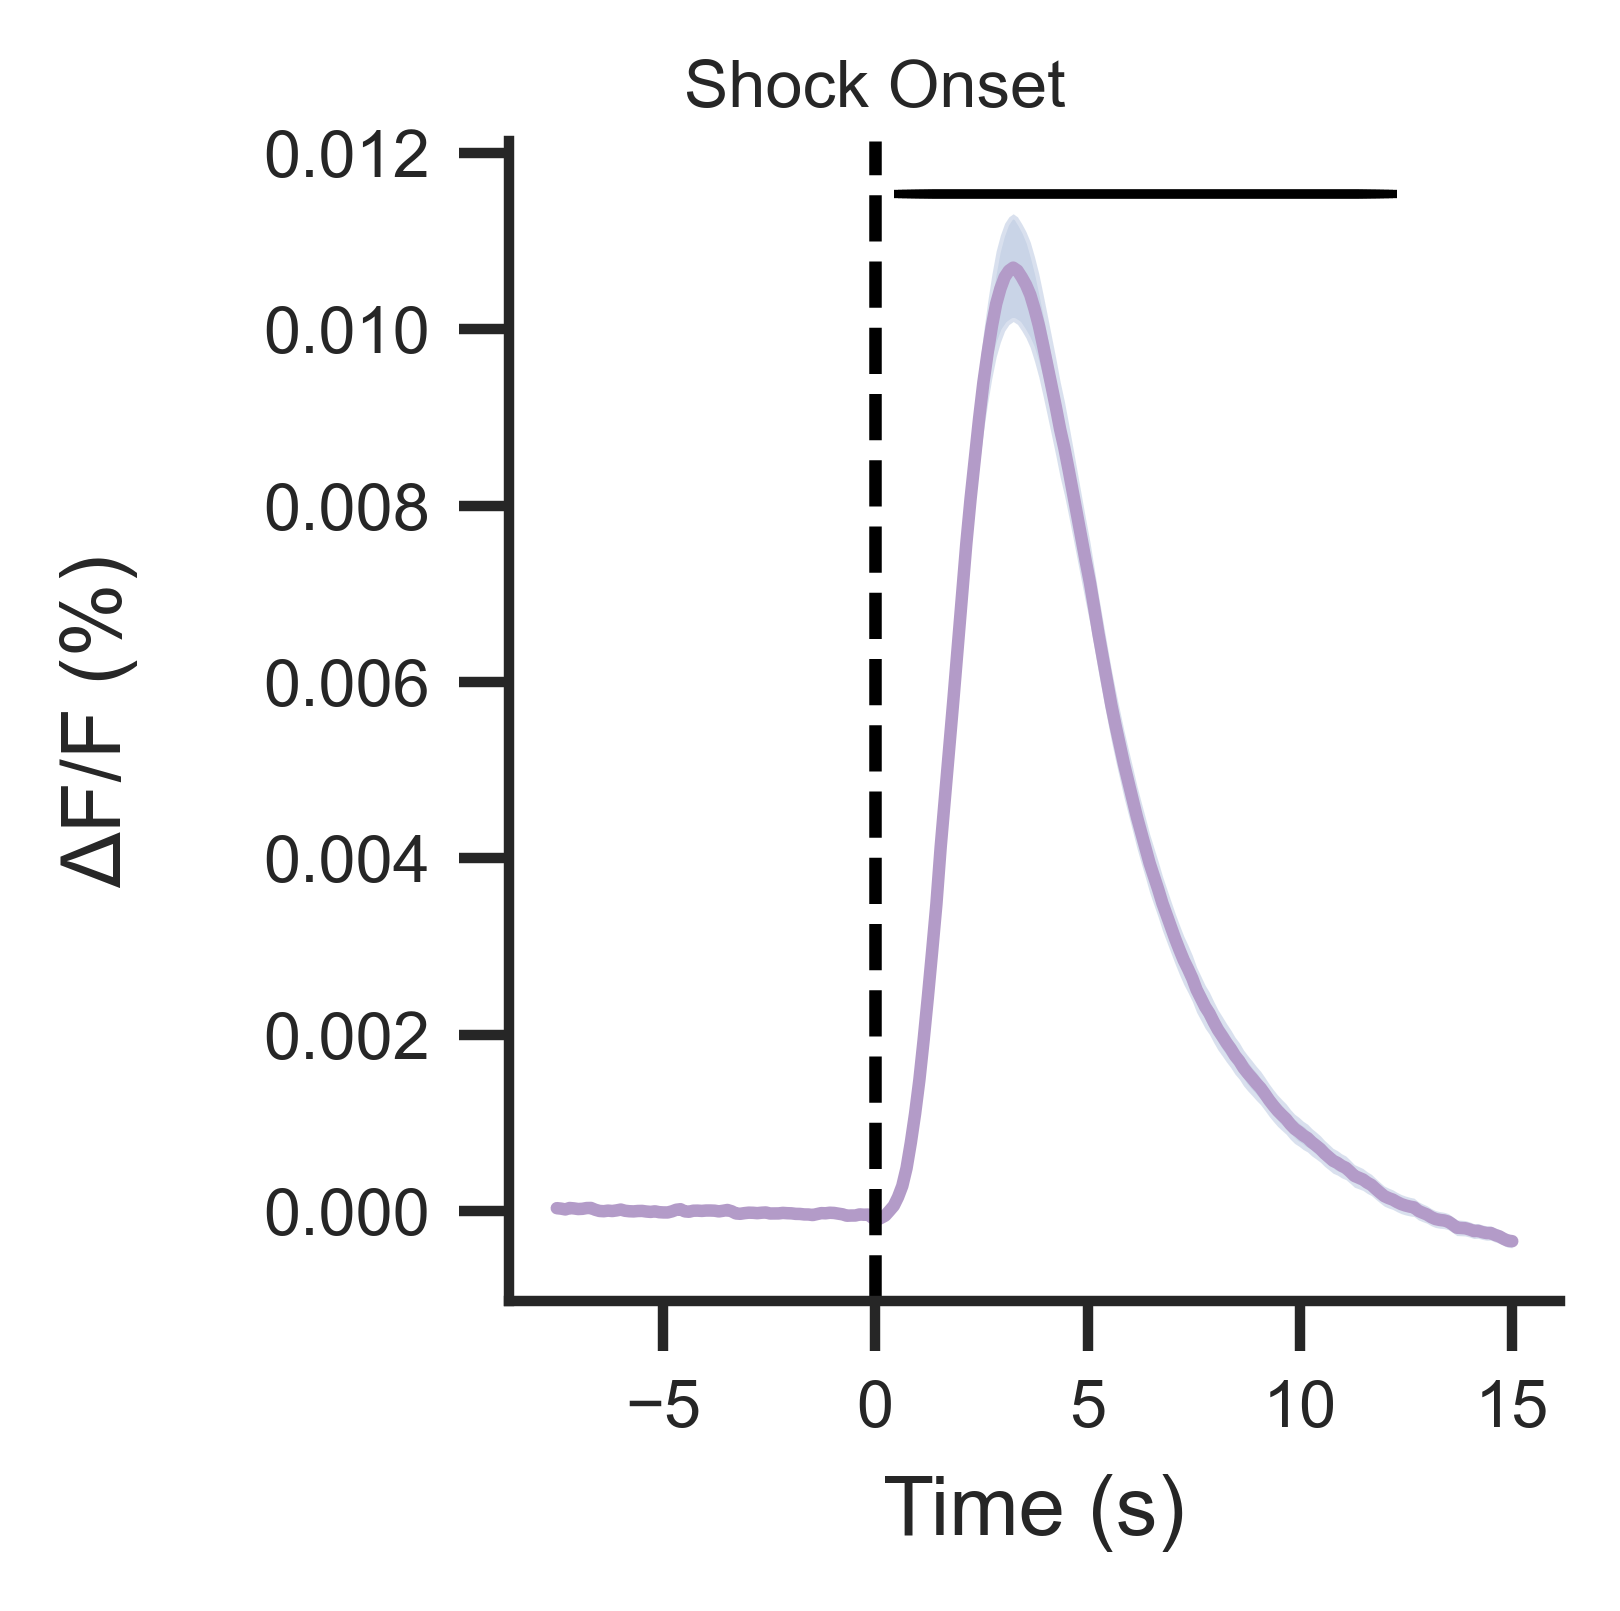

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='ΔF/F (%)'>)

In [40]:
#Run your plot
timestamps = collection_fc.animals['astroM4'].Timestamps[:3303].to_numpy().squeeze()
shock_events = [[120, 180, 240, 300]]
plot_shock_eta_all(fcA_array, timestamps, shock_events, save_path=r'/Users/suthardr/Desktop/shock_eta_allmice_10sigduration_baselinecorr_tci95.svg')

In [41]:
#Plot by sex
def plot_shock_eta_groups(group_data, group_labels, timestamps, events, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

    # Define colors for the groups
    group_colors = {'Female': '#B39BC8', 'Male': '#8CCFD0'}  # Lavender & Sky Blue

    for data, label in zip(group_data, group_labels):
        shock_eta_all(data.T, timestamps, events=events, window=15, ci='tci', ax=ax,
                      color=group_colors.get(label, 'gray'), label=label)

    ax.axvline(x=0, color='black', linestyle='--')
    ax.text(0, ax.get_ylim()[1] * 1.02, 'Shock Onset', ha='center', va='bottom', fontsize=8, fontname='Arial')

    ax.set_ylabel(r"ΔF/F (%)", fontsize=10, fontname='Arial', labelpad=15)
    ax.set_xlabel('Time (s)', fontsize=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    ax.set_title(title, fontsize=10, pad=10, fontname='Arial')

    # Add legend
    ax.legend(title="Sex", fontsize=7, title_fontsize=8, frameon=False, loc='upper right')

    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')

    plt.show()
    return fig, ax


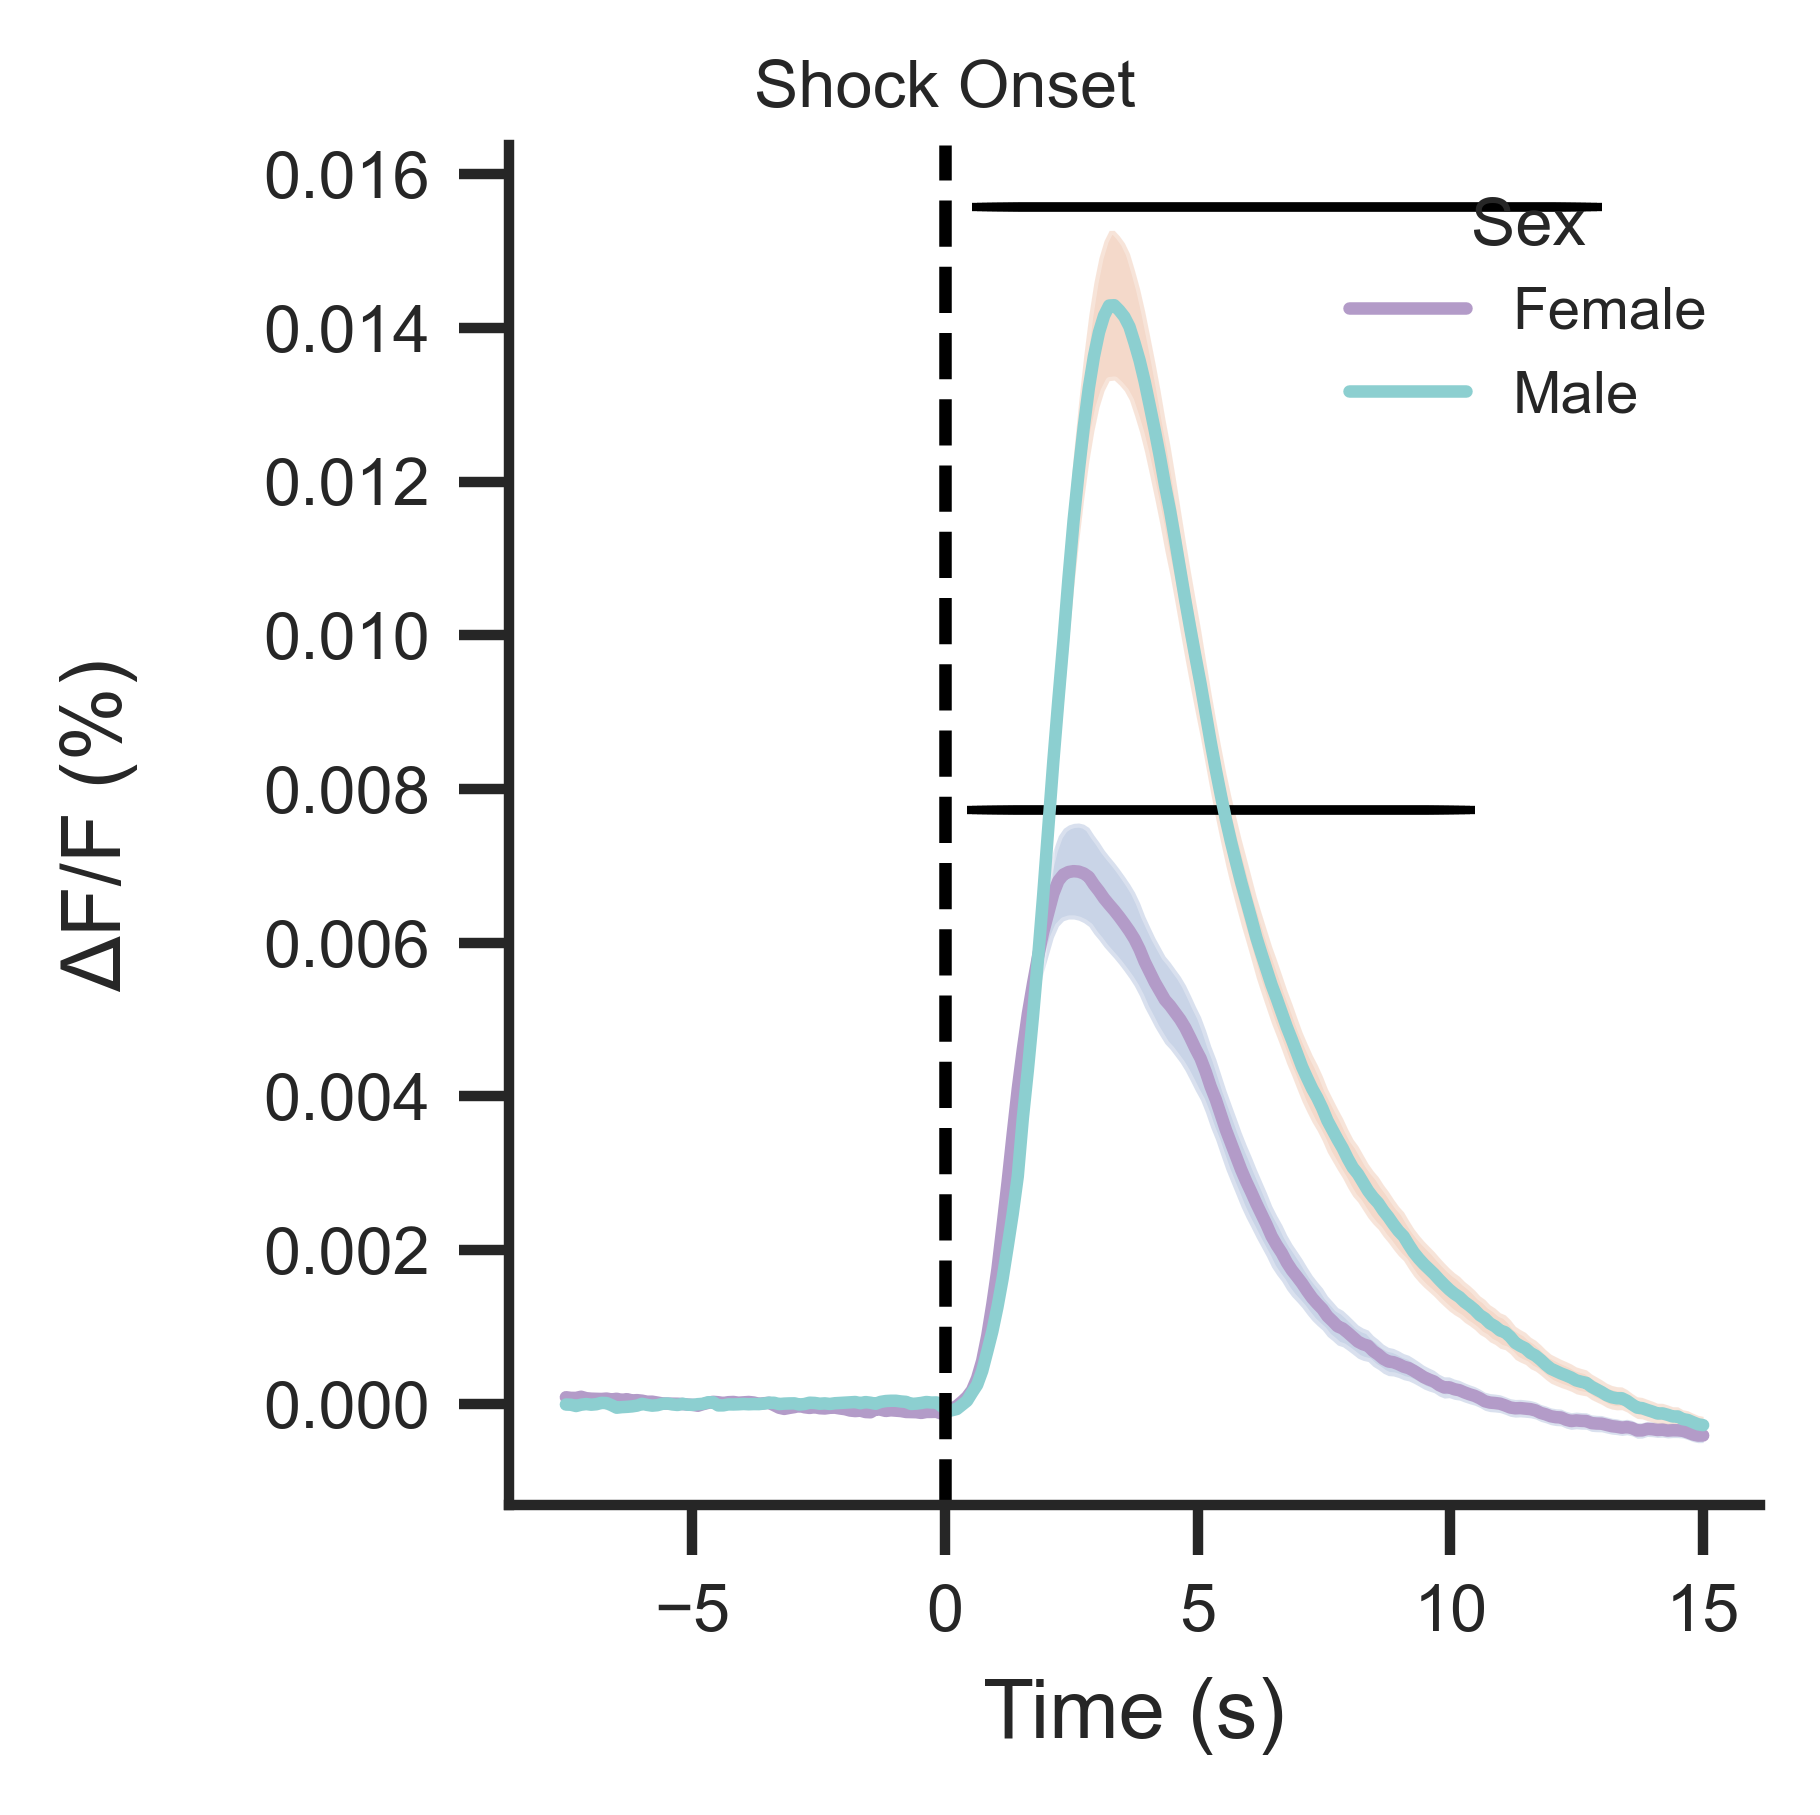

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='ΔF/F (%)'>)

In [51]:
# Split IDs by sex
female_ids = [m for m in mouse_ids if 'F' in m]
male_ids = [m for m in mouse_ids if 'M' in m]

# Get traces
fcA_female = get_traces(collection_fc, female_ids)
fcA_male = get_traces(collection_fc, male_ids)

# Use common timestamps (adjust if needed)
timestamps = collection_fc.animals['astroM4'].Timestamps[:3303].to_numpy().squeeze()
shock_events = [[120, 180, 240, 300]]

# Plot both on same figure
plot_shock_eta_groups(
    group_data=[fcA_female, fcA_male],
    group_labels=["Female", "Male"],
    timestamps=timestamps,
    events=shock_events,
save_path=r'/Users/suthardr/Desktop/shock_eta_sexsplit_10sigduration_baselinecorr_tci95.svg')


In [44]:
from scipy.stats import ttest_ind, mannwhitneyu
import numpy as np

def extract_peak_response(data, timestamps, events, window=15, post_shock_window=(0, 5)):
    sampling_rate = 10
    n_points = int(window * 1.5 * sampling_rate)
    time = np.linspace(-window / 2, window, n_points)

    def event_interpolation(signal, event_times):
        interp = scipy.interpolate.interp1d(timestamps, signal, kind='cubic', fill_value="extrapolate")
        eta_curves = np.array([
            interp(np.linspace(e - window / 2, e + window, n_points))
            for e in event_times
        ])
        return eta_curves.mean(axis=0)

    across_eta_ = np.array([
        event_interpolation(signal, events[0]) for signal in data
    ])

    # Subtract baseline (-5 to -3s)
    baseline_idx = np.where((time >= -5) & (time <= -3))[0]
    baseline_mean = across_eta_[:, baseline_idx].mean(axis=1, keepdims=True)
    across_eta_ -= baseline_mean

    # Get indices for peak window
    peak_idx = np.where((time >= post_shock_window[0]) & (time <= post_shock_window[1]))[0]
    peak_values = across_eta_[:, peak_idx].max(axis=1)

    return peak_values

In [45]:
# Get peak responses
female_peaks = extract_peak_response(fcA_female.T, timestamps, shock_events)
male_peaks = extract_peak_response(fcA_male.T, timestamps, shock_events)

import pandas as pd

peak_df = pd.DataFrame({
    'ΔF/F (%)': np.concatenate([female_peaks, male_peaks]),
    'Sex': ['Female'] * len(female_peaks) + ['Male'] * len(male_peaks)
})


In [46]:
peak_df

,ΔF/F (%),Sex
0,0.011809,Female
1,0.009339,Female
2,0.019978,Female
3,0.020619,Female
4,0.015660,Female
...,...,...
3127,0.019476,Male
3128,0.012190,Male
3129,0.015397,Male
3130,0.016503,Male


In [47]:
#Filter df by male and female
male_df = peak_df[peak_df['Sex'].isin(['Male'])]
female_df = peak_df[peak_df['Sex'].isin(['Female'])]

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_68178/1643562836.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(male_df['ΔF/F (%)'], color="#8CCFD0", label="Male", hist_kws={'alpha':.7}, kde_kws={'linewidth':2})
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_68178/1643562836.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github

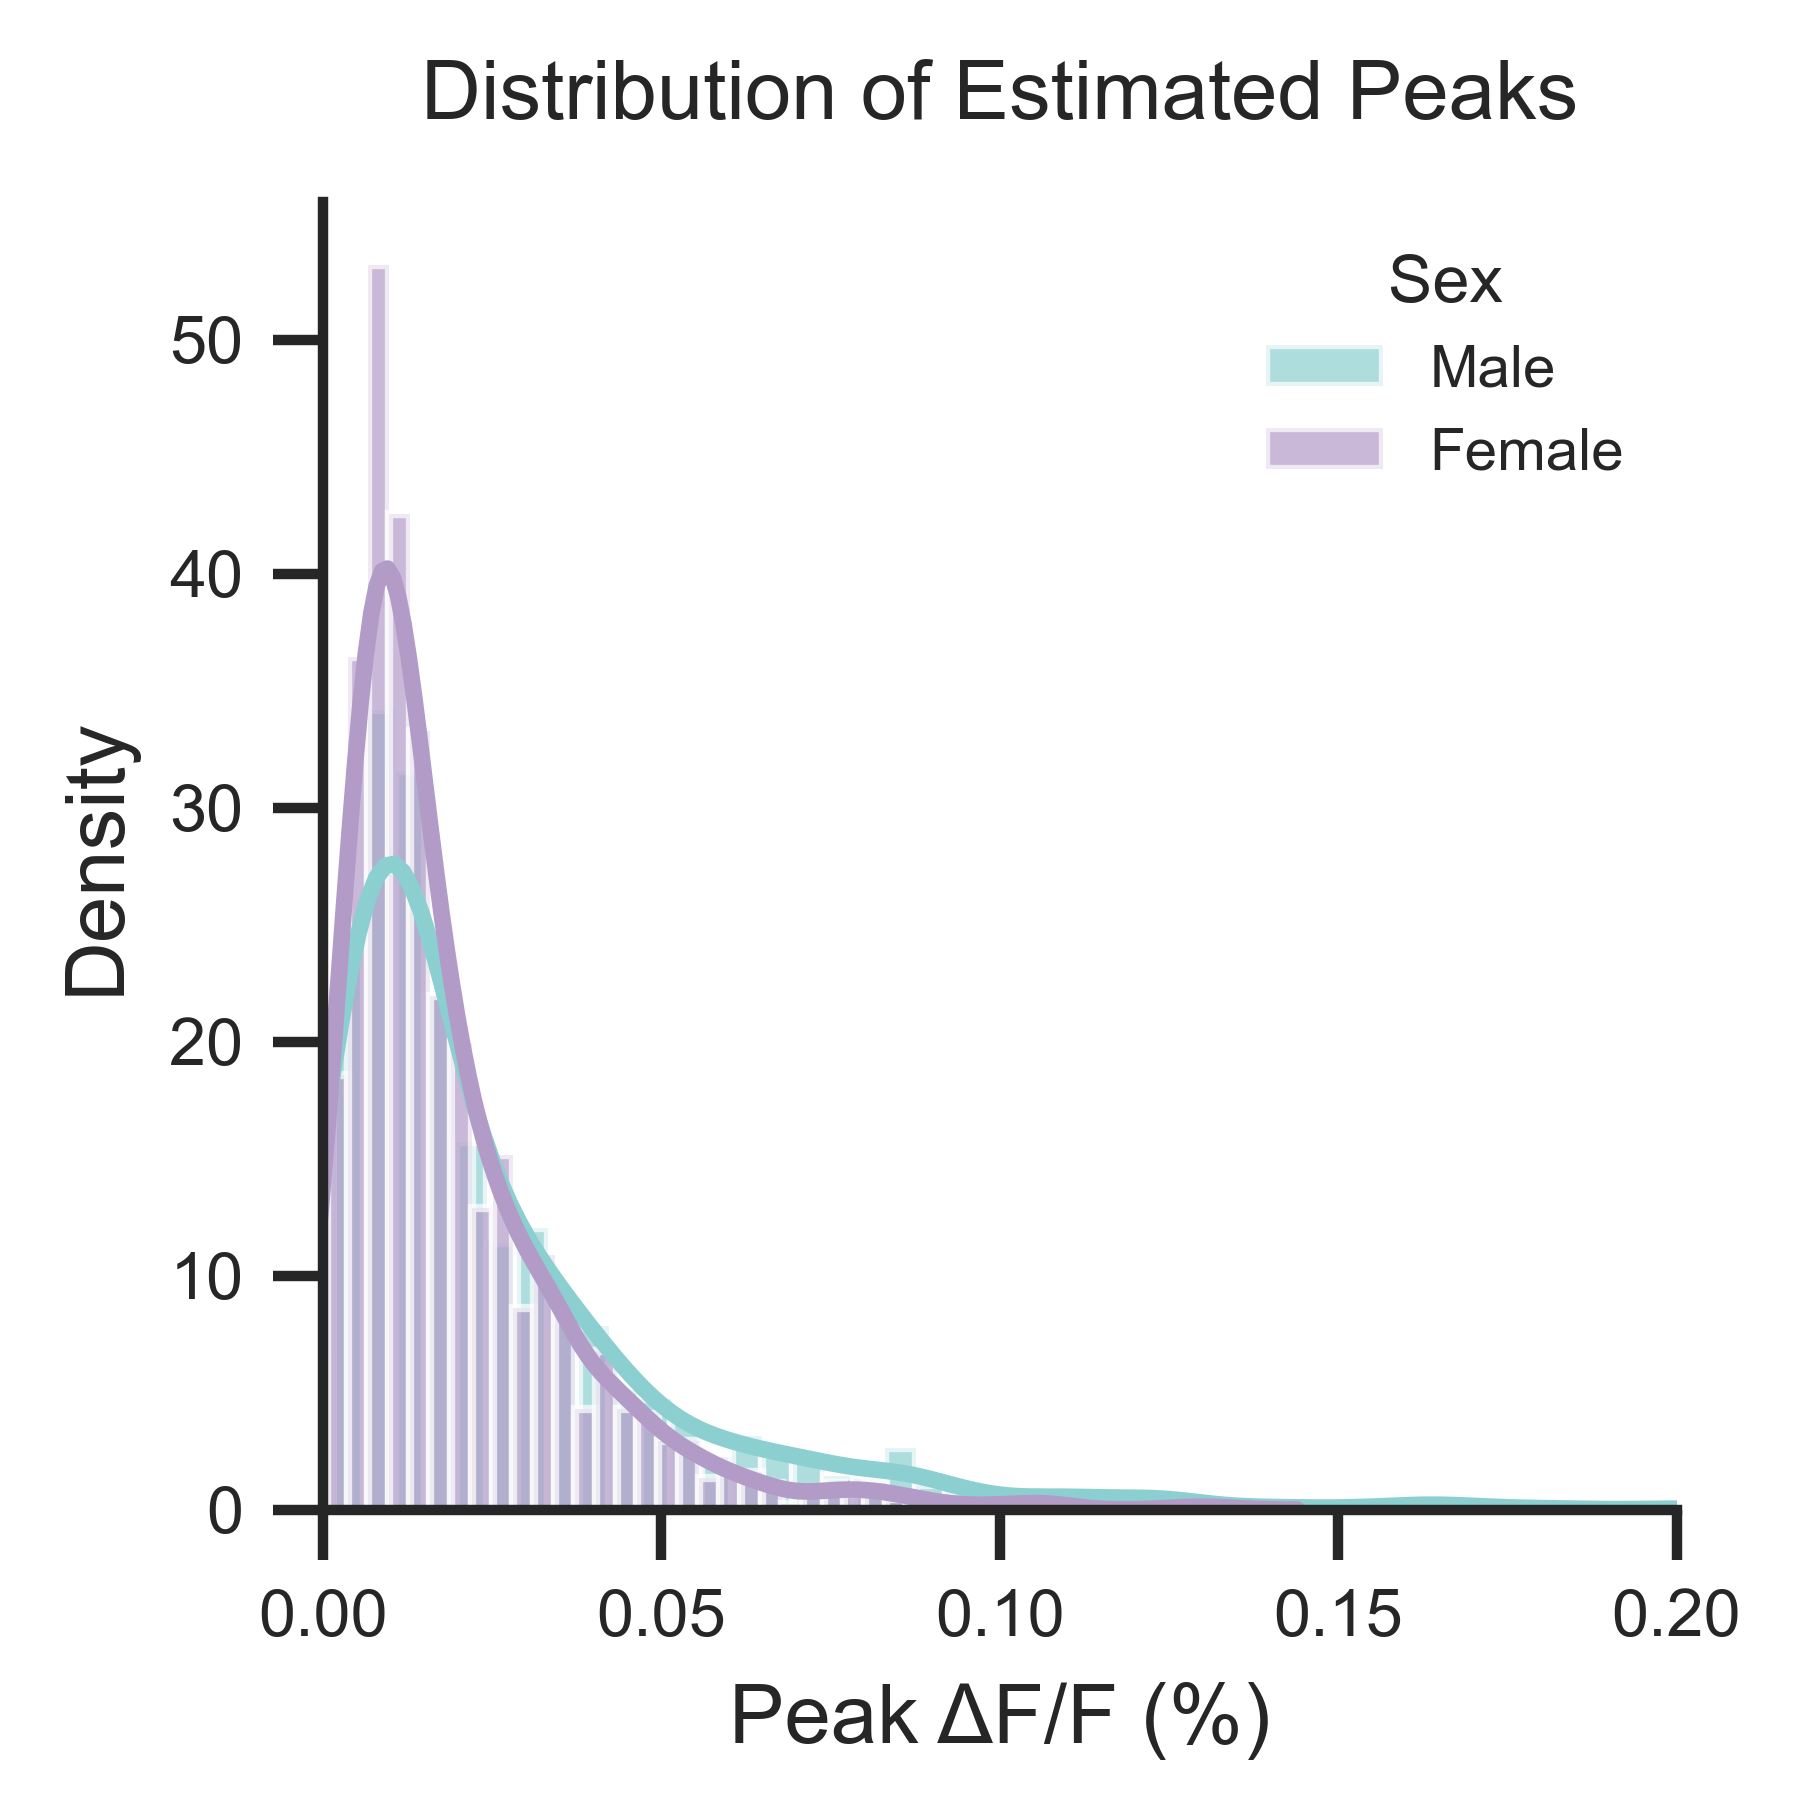

In [49]:
#Plot the histogram
sns.set(style="ticks", font="Arial")
plt.rcParams.update({'font.size': 8})
fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
ax.set_xlim([0,0.2])
ax.set_xlabel('Time (s)', fontsize=10, fontname='Arial')
ax.set_ylabel('Density',fontsize=10, fontname='Arial')
ax.grid(False)
sns.despine(ax=ax)
sns.distplot(male_df['ΔF/F (%)'], color="#8CCFD0", label="Male", hist_kws={'alpha':.7}, kde_kws={'linewidth':2})
sns.distplot(female_df['ΔF/F (%)'], color="#B39BC8", label="Female", hist_kws={'alpha':.7}, kde_kws={'linewidth':2})

ax.set_title('Distribution of Estimated Peaks',fontsize=10, fontname='Arial', pad=10)
ax.set_xlabel('Peak ΔF/F (%)',fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.legend(title="Sex", fontsize=7, title_fontsize=8, frameon=False, loc='upper right')
plt.tight_layout(pad=3)
fig.savefig('/Users/suthardr/Desktop/peak_dist_shock_bysex.svg')